# Simulation Benchmark Pipeline and Visualization

This notebook runs the main simulation benchmark workflow and the summary visualization in one place.

It can:
1. optionally run the local benchmark scripts for **SpiderNet**, **COMMOT**, and **NMF-LR**,
2. merge benchmark outputs from **five methods** (**SpiderNet**, **COMMOT**, **Spacia**, **NMF-LR**, and **ScCChain**), and
3. generate summary plots and statistical tables for AUROC, AUPRC, and the **SpiderNet loading block-mass ratio**.

The slower in-situ comparison is intentionally kept in a separate notebook.


In [1]:
from pathlib import Path
from itertools import combinations
import subprocess
import sys
import warnings

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu, ttest_1samp
from IPython.display import display

warnings.filterwarnings("ignore")

plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 8
plt.rcParams["axes.labelsize"] = 8
plt.rcParams["axes.titlesize"] = 8
plt.rcParams["xtick.labelsize"] = 7
plt.rcParams["ytick.labelsize"] = 7
plt.rcParams["axes.linewidth"] = 0.8
plt.rcParams["xtick.major.width"] = 0.8
plt.rcParams["ytick.major.width"] = 0.8
plt.rcParams["xtick.major.size"] = 3
plt.rcParams["ytick.major.size"] = 3

# ------------------------------------------------------------
# 0. Configuration
# ------------------------------------------------------------
RUN_SpiderNet = True
# RUN_COMMOT = True
# RUN_NMF_LR = True
RUN_COMMOT = False
RUN_NMF_LR = False

SETTING_INDICES = list(range(6))
EXPERIMENT_INDICES = list(range(30))

SETTING_LIST = [
    "Dropout1", "Dropout2", "Dropout3",
    "Sd_use1", "Sd_use2", "Sd_use3",
]

PYTHON_PATH = sys.executable

SPIDERNET_SCRIPT = r"D:/SpiderNet/SpiderNet_proj/SpiderNet_Project/Tutorial/Simulation/SpiderNet_Simulation.py"
COMMOT_SCRIPT = r"D:/SpiderNet/SpiderNet_proj/SpiderNet_Project/Tutorial/Simulation/COMMOT_Simulation.py"
NMF_LR_SCRIPT = r"D:/SpiderNet/SpiderNet_proj/SpiderNet_Project/Tutorial/Simulation/NMF_LR_Simulation.py"

SPIDERNET_RESULT_ROOT = Path(r"D:/SpiderNet/Results/Simulation/SpiderNet")
COMMOT_RESULT_ROOT = Path(r"D:/SpiderNet/Results/Simulation/COMMOT")
NMF_LR_RESULT_ROOT = Path(r"D:/SpiderNet/Results/Simulation/NMF_LR")
SCCCHAIN_ANALYSIS_ROOT = Path(r"D:/SpiderNet/Results/Simulation/ScCChain_analysis")
SPACIA_ANALYSIS_ROOT = Path(r"E:/project_SpiderNet/Simulation/Spacia_analysis")

MERGED_RESULT_ROOT = Path(r"D:/SpiderNet/Results/Simulation/Merged_Benchmark")
MERGED_RESULT_ROOT.mkdir(parents=True, exist_ok=True)

METHOD_ORDER = ["SpiderNet", "COMMOT", "Spacia", "NMF-LR", "ScCChain"]
LOADING_ORDER = [
    "LR Loading Rank Ratio",
    "Sending Loading Rank Ratio",
    "Receiving Loading Rank Ratio",
]


In [2]:
# ------------------------------------------------------------
# 1. Optional method runners
# ------------------------------------------------------------

def run_method_grid(script_path, setting_indices, experiment_indices):
    for setting_idx in setting_indices:
        for experiment_idx in experiment_indices:
            command = [
                PYTHON_PATH,
                script_path,
                "--setting", str(setting_idx),
                "--experiment", str(experiment_idx),
            ]
            print("Running:", " ".join(command))
            subprocess.run(command, check=True)

if RUN_SpiderNet:
    run_method_grid(
        script_path=SPIDERNET_SCRIPT,
        setting_indices=SETTING_INDICES,
        experiment_indices=EXPERIMENT_INDICES,
    )
else:
    print("RUN_SpiderNet is False. Skipping SpiderNet execution.")

if RUN_COMMOT:
    run_method_grid(
        script_path=COMMOT_SCRIPT,
        setting_indices=SETTING_INDICES,
        experiment_indices=EXPERIMENT_INDICES,
    )
else:
    print("RUN_COMMOT is False. Skipping COMMOT execution.")

if RUN_NMF_LR:
    run_method_grid(
        script_path=NMF_LR_SCRIPT,
        setting_indices=SETTING_INDICES,
        experiment_indices=EXPERIMENT_INDICES,
    )
else:
    print("RUN_NMF_LR is False. Skipping NMF-LR execution.")


Running: C:\Users\junji\miniconda3\envs\SpiderNet_env\python.exe D:/SpiderNet/SpiderNet_proj/SpiderNet_Project/Tutorial/Simulation/SpiderNet_Simulation.py --setting 0 --experiment 0
Running: C:\Users\junji\miniconda3\envs\SpiderNet_env\python.exe D:/SpiderNet/SpiderNet_proj/SpiderNet_Project/Tutorial/Simulation/SpiderNet_Simulation.py --setting 0 --experiment 1
Running: C:\Users\junji\miniconda3\envs\SpiderNet_env\python.exe D:/SpiderNet/SpiderNet_proj/SpiderNet_Project/Tutorial/Simulation/SpiderNet_Simulation.py --setting 0 --experiment 2
Running: C:\Users\junji\miniconda3\envs\SpiderNet_env\python.exe D:/SpiderNet/SpiderNet_proj/SpiderNet_Project/Tutorial/Simulation/SpiderNet_Simulation.py --setting 0 --experiment 3
Running: C:\Users\junji\miniconda3\envs\SpiderNet_env\python.exe D:/SpiderNet/SpiderNet_proj/SpiderNet_Project/Tutorial/Simulation/SpiderNet_Simulation.py --setting 0 --experiment 4
Running: C:\Users\junji\miniconda3\envs\SpiderNet_env\python.exe D:/SpiderNet/SpiderNet_pr

In [12]:
# ------------------------------------------------------------
# 2. Readers
# ------------------------------------------------------------

def read_local_macro_metrics(csv_path, setting_name, experiment_idx):
    if not csv_path.is_file():
        return None
    df = pd.read_csv(csv_path)
    if df.shape[0] == 0:
        return None
    out = df.copy()
    out["Setting"] = setting_name
    out["Experiment"] = experiment_idx
    return out


def read_external_macro_metrics(csv_path, method_name, setting_name, experiment_idx):
    if not csv_path.is_file():
        return None
    df = pd.read_csv(csv_path)
    if df.shape[0] == 0:
        return None
    row = df.iloc[0]
    return pd.DataFrame([
        {
            "Method": method_name,
            "Macro_AUROC": row.get("Macro_AUROC", float("nan")),
            "Macro_AUPRC": row.get("Macro_AUPRC", float("nan")),
            "Setting": setting_name,
            "Experiment": experiment_idx,
        }
    ])


def read_loading_summary(csv_path, setting_name, experiment_idx):
    if not csv_path.is_file():
        return None
    df = pd.read_csv(csv_path)
    if df.shape[0] == 0:
        return None
    out = df.copy()
    out["Setting"] = setting_name
    out["Experiment"] = experiment_idx
    return out


def reorder_method_column(df, col="Method"):
    if df is None or df.shape[0] == 0 or col not in df.columns:
        return df
    df = df.copy()
    seen = [m for m in METHOD_ORDER if m in df[col].astype(str).tolist()]
    other = [m for m in df[col].astype(str).drop_duplicates().tolist() if m not in seen]
    df[col] = pd.Categorical(df[col], categories=seen + other, ordered=True)
    return df


In [13]:
# ------------------------------------------------------------
# 3. Merge benchmark outputs across five methods
# ------------------------------------------------------------
macro_list = []
loading_list = []

for setting_idx in SETTING_INDICES:
    setting_name = SETTING_LIST[setting_idx]

    for experiment_idx in EXPERIMENT_INDICES:
        exp_folder = f"Experiment_{experiment_idx}"
        sample_name = f"{setting_name}_{exp_folder}"

        spider_dir = SPIDERNET_RESULT_ROOT / setting_name / exp_folder / "SpiderNet_Result_Mode_cell_class"
        commot_dir = COMMOT_RESULT_ROOT / setting_name / exp_folder / "COMMOT_Result"
        nmf_lr_dir = NMF_LR_RESULT_ROOT / setting_name / exp_folder / "NMF_LR_Result"

        local_metric_paths = [
            spider_dir / "Benchmark_MacroMetrics.csv",
            commot_dir / "Benchmark_MacroMetrics.csv",
            nmf_lr_dir / "Benchmark_MacroMetrics.csv",
        ]
        for csv_path in local_metric_paths:
            df = read_local_macro_metrics(
                csv_path,
                setting_name=setting_name,
                experiment_idx=experiment_idx,
            )
            if df is not None:
                macro_list.append(df)

        local_loading_paths = [
            spider_dir / "LoadingRank_Ratio_Summary.csv",
            commot_dir / "LoadingRank_Ratio_Summary.csv",
            nmf_lr_dir / "LoadingRank_Ratio_Summary.csv",
        ]
        for csv_path in local_loading_paths:
            df = read_loading_summary(
                csv_path,
                setting_name=setting_name,
                experiment_idx=experiment_idx,
            )
            if df is not None:
                loading_list.append(df)

        sccchain_metrics_csv = SCCCHAIN_ANALYSIS_ROOT / setting_name / exp_folder / f"{sample_name}_metrics.csv"
        spacia_metrics_csv = SPACIA_ANALYSIS_ROOT / setting_name / exp_folder / f"{sample_name}_metrics.csv"

        sccchain_df = read_external_macro_metrics(
            sccchain_metrics_csv,
            method_name="ScCChain",
            setting_name=setting_name,
            experiment_idx=experiment_idx,
        )
        spacia_df = read_external_macro_metrics(
            spacia_metrics_csv,
            method_name="Spacia",
            setting_name=setting_name,
            experiment_idx=experiment_idx,
        )

        if sccchain_df is not None:
            macro_list.append(sccchain_df)
        if spacia_df is not None:
            macro_list.append(spacia_df)

        print(f"Processed: {setting_name} | {exp_folder}")

macro_all = pd.concat(macro_list, axis=0, ignore_index=True) if len(macro_list) > 0 else pd.DataFrame()
loading_all = pd.concat(loading_list, axis=0, ignore_index=True) if len(loading_list) > 0 else pd.DataFrame()

macro_all = reorder_method_column(macro_all)
loading_all = reorder_method_column(loading_all)

auroc_all = macro_all[["Method", "Macro_AUROC", "Setting", "Experiment"]].rename(
    columns={"Macro_AUROC": "values"}
)
auprc_all = macro_all[["Method", "Macro_AUPRC", "Setting", "Experiment"]].rename(
    columns={"Macro_AUPRC": "values"}
)

if loading_all.shape[0] > 0 and "Method" in loading_all.columns:
    loading_spidernet = loading_all[loading_all["Method"].astype(str) == "SpiderNet"].copy()
else:
    loading_spidernet = pd.DataFrame()

macro_all.to_csv(MERGED_RESULT_ROOT / "Benchmark_MacroMetrics_all_five_methods.csv", index=False)
auroc_all.to_csv(MERGED_RESULT_ROOT / "AUROC_macro_all_five_methods.csv", index=False)
auprc_all.to_csv(MERGED_RESULT_ROOT / "AUPRC_macro_all_five_methods.csv", index=False)
loading_all.to_csv(MERGED_RESULT_ROOT / "LoadingRank_Ratio_Summary_all_available_methods.csv", index=False)
loading_spidernet.to_csv(MERGED_RESULT_ROOT / "LoadingRank_Ratio_Summary_SpiderNet.csv", index=False)

print("Saved merged benchmark tables to:", MERGED_RESULT_ROOT)
display(macro_all.head())
display(loading_spidernet.head())


Processed: Dropout1 | Experiment_0
Processed: Dropout1 | Experiment_1
Processed: Dropout1 | Experiment_2
Processed: Dropout1 | Experiment_3
Processed: Dropout1 | Experiment_4
Processed: Dropout1 | Experiment_5
Processed: Dropout1 | Experiment_6
Processed: Dropout1 | Experiment_7
Processed: Dropout1 | Experiment_8
Processed: Dropout1 | Experiment_9
Processed: Dropout1 | Experiment_10
Processed: Dropout1 | Experiment_11
Processed: Dropout1 | Experiment_12
Processed: Dropout1 | Experiment_13
Processed: Dropout1 | Experiment_14
Processed: Dropout1 | Experiment_15
Processed: Dropout1 | Experiment_16
Processed: Dropout1 | Experiment_17
Processed: Dropout1 | Experiment_18
Processed: Dropout1 | Experiment_19
Processed: Dropout1 | Experiment_20
Processed: Dropout1 | Experiment_21
Processed: Dropout1 | Experiment_22
Processed: Dropout1 | Experiment_23
Processed: Dropout1 | Experiment_24
Processed: Dropout1 | Experiment_25
Processed: Dropout1 | Experiment_26
Processed: Dropout1 | Experiment_27
Pr

,Method,Macro_AUROC,Macro_AUPRC,Setting,Experiment
0,SpiderNet,0.994166,0.880695,Dropout1,0
1,COMMOT,0.447922,0.194538,Dropout1,0
2,NMF-LR,0.979730,0.765321,Dropout1,0
3,ScCChain,0.644565,0.278359,Dropout1,0
4,Spacia,0.501084,0.014549,Dropout1,0


,Method,LR_loading_ratio,Sender_loading_ratio,Receiver_loading_ratio,MI1_component,MI2_component,Metric_definition,Normalization,Scoring,Setting,Experiment
0,SpiderNet,0.889035,0.955722,0.964446,1.0,0.0,Trained loading rank ratio using legacy-style ...,column_normalized_trained_loading,"mean(correct_component_share, top1_hit_ratio)_...",Dropout1,0
3,SpiderNet,0.889365,0.980696,0.897569,0.0,1.0,Trained loading rank ratio using legacy-style ...,column_normalized_trained_loading,"mean(correct_component_share, top1_hit_ratio)_...",Dropout1,1
6,SpiderNet,0.890801,0.920870,0.974381,0.0,1.0,Trained loading rank ratio using legacy-style ...,column_normalized_trained_loading,"mean(correct_component_share, top1_hit_ratio)_...",Dropout1,2
9,SpiderNet,0.888422,0.924871,0.961464,1.0,0.0,Trained loading rank ratio using legacy-style ...,column_normalized_trained_loading,"mean(correct_component_share, top1_hit_ratio)_...",Dropout1,3
12,SpiderNet,0.889854,0.992076,0.980857,0.0,1.0,Trained loading rank ratio using legacy-style ...,column_normalized_trained_loading,"mean(correct_component_share, top1_hit_ratio)_...",Dropout1,4


## Visualization and summary statistics

This section reads the merged benchmark tables generated above and produces:
- AUROC summary plots and tables,
- AUPRC summary plots and tables,
- **SpiderNet-only** loading block-mass ratio summary plots and tables, and
- simple statistical comparison tables.


In [14]:
# ------------------------------------------------------------
# 4. Visualization configuration
# ------------------------------------------------------------
SUMMARY_OUT_DIR = MERGED_RESULT_ROOT / "Summary_Plots"
SUMMARY_OUT_DIR.mkdir(parents=True, exist_ok=True)

AUPRC_FILE = MERGED_RESULT_ROOT / "AUPRC_macro_all_five_methods.csv"
AUROC_FILE = MERGED_RESULT_ROOT / "AUROC_macro_all_five_methods.csv"
LOADING_FILE = MERGED_RESULT_ROOT / "LoadingRank_Ratio_Summary_SpiderNet.csv"

METHOD_LIST = METHOD_ORDER.copy()

EDGE_PALETTE = {
    "SpiderNet": "#E43329",
    "COMMOT": "#519384",
    "Spacia": "#FED881",
    "NMF-LR": "#82CCE2",
    "ScCChain": "#636491",
}

FILL_PALETTE = {
    "SpiderNet": "#F497B4",
    "COMMOT": "#B9CEC7",
    "Spacia": "#FFF2D2",
    "NMF-LR": "#D4ECF1",
    "ScCChain": "#A6A2B9",
}

LOADING_ORDER = [
    "LR Loading Rank Ratio",
    "Sending Loading Rank Ratio",
    "Receiving Loading Rank Ratio",
]

LOADING_EDGE_PALETTE = {
    "LR Loading Rank Ratio": "#F19B5B",
    "Sending Loading Rank Ratio": "#86CAE1",
    "Receiving Loading Rank Ratio": "#E43329",
}

LOADING_FILL_PALETTE = {
    "LR Loading Rank Ratio": "#FFF4D4",
    "Sending Loading Rank Ratio": "#D4ECF1",
    "Receiving Loading Rank Ratio": "#F497B4",
}


In [15]:
# ------------------------------------------------------------
# 5. Visualization helpers
# ------------------------------------------------------------
def add_setting_metadata(df, setting_col="Setting"):
    df = df.copy()
    df["setting_type"] = np.where(
        df[setting_col].astype(str).str.startswith("Dropout"),
        "Dropout",
        np.where(
            df[setting_col].astype(str).str.startswith("Sd_use"),
            "Sd_use",
            "Other",
        ),
    )
    df[setting_col] = pd.Categorical(df[setting_col], categories=SETTING_LIST, ordered=True)
    df["setting_type"] = pd.Categorical(
        df["setting_type"],
        categories=["Dropout", "Sd_use", "Other"],
        ordered=True,
    )
    return df


def load_metric_table(csv_path, method_list):
    csv_path = Path(csv_path)
    if not csv_path.is_file():
        raise FileNotFoundError(f"Cannot find input file: {csv_path}")

    df = pd.read_csv(csv_path)
    if "Method" not in df.columns:
        raise ValueError(f"'Method' column is missing in {csv_path}")

    df = df[df["Method"].isin(method_list)].copy()
    df["Method"] = pd.Categorical(df["Method"], categories=method_list, ordered=True)
    df = add_setting_metadata(df, setting_col="Setting")
    return df


def normalize_loading_table(df):
    df = df.copy()

    if "Method" in df.columns:
        df["Method"] = df["Method"].replace({
            "SpiderNet": "SpiderNet",
            "NMF+LR": "NMF-LR",
        })

    if {"Loading", "LoadingRank_Ratio"}.issubset(df.columns):
        out = df.copy()
    else:
        id_cols = [c for c in ["Method", "Setting", "Experiment"] if c in df.columns]

        canonical_map = {}
        for col in df.columns:
            key = str(col).strip().lower().replace("_", " ").replace("-", " ")
            key = " ".join(key.split())
            if "ratio" not in key:
                continue
            if "receiv" in key:
                canonical_map[col] = "Receiving Loading Rank Ratio"
            elif "send" in key:
                canonical_map[col] = "Sending Loading Rank Ratio"
            elif key.startswith("lr ") or " lr " in f" {key} ":
                canonical_map[col] = "LR Loading Rank Ratio"

        if len(canonical_map) == 0:
            raise ValueError(
                "Cannot identify loading-ratio columns. "
                f"Available columns: {df.columns.tolist()}"
            )

        out = (
            df[id_cols + list(canonical_map.keys())]
            .rename(columns=canonical_map)
            .melt(
                id_vars=id_cols,
                value_vars=[c for c in LOADING_ORDER if c in canonical_map.values()],
                var_name="Loading",
                value_name="LoadingRank_Ratio",
            )
        )

    required_cols = {"Setting", "Loading", "LoadingRank_Ratio"}
    missing_cols = required_cols - set(out.columns)
    if missing_cols:
        raise ValueError(
            "Loading table is missing required columns after normalization: "
            f"{sorted(missing_cols)}"
        )

    if "Method" in out.columns:
        out["Method"] = pd.Categorical(out["Method"], categories=METHOD_ORDER, ordered=True)

    out["Loading"] = pd.Categorical(out["Loading"], categories=LOADING_ORDER, ordered=True)
    out = add_setting_metadata(out, setting_col="Setting")
    return out



def export_metric_tables(df, value_col, stem):
    long_out = df[["Setting", "Experiment", "Method", value_col]].copy()
    wide_out = long_out.pivot_table(
        index=["Setting", "Experiment"],
        columns="Method",
        values=value_col,
        aggfunc="first",
    ).reset_index()

    found_summary = (
        long_out[["Setting", "Experiment"]]
        .drop_duplicates()
        .groupby("Setting", as_index=False)
        .size()
        .rename(columns={"size": "n_found_experiments"})
    )

    long_out.to_csv(SUMMARY_OUT_DIR / f"{stem}_long.csv", index=False)
    wide_out.to_csv(SUMMARY_OUT_DIR / f"{stem}_wide.csv", index=False)
    found_summary.to_csv(SUMMARY_OUT_DIR / f"{stem}_found_summary.csv", index=False)

    return long_out, wide_out, found_summary


def summarize_metric(df, value_col, stem):
    summary = (
        df.groupby(["Setting", "Method"], observed=False)[value_col]
        .agg(["mean", "std", "count"])
        .reset_index()
        .rename(columns={"mean": "mean_val", "std": "sd_val", "count": "n"})
    )
    summary.to_csv(SUMMARY_OUT_DIR / f"{stem}_summary_by_setting_method.csv", index=False)
    return summary


def _style_axis(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", direction="out")
    ax.grid(False)


def _draw_grouped_boxplot(
    ax,
    df,
    group_values,
    hue_values,
    y_col,
    edge_palette,
    fill_palette,
    ylabel,
):
    n_hue = len(hue_values)
    x_positions = np.arange(len(group_values)) + 1
    group_width = 0.8
    offsets = np.linspace(-group_width / 2, group_width / 2, n_hue)

    legend_handles = []

    for h_idx, hue_value in enumerate(hue_values):
        data_list = []
        positions = []

        for x_idx, group_value in enumerate(group_values):
            vals = (
                df[(df["Setting"] == group_value) & (df["Method"] == hue_value)][y_col]
                .dropna()
                .to_numpy()
            )
            if vals.size == 0:
                vals = np.array([np.nan])
            data_list.append(vals)
            positions.append(x_positions[x_idx] + offsets[h_idx])

        bp = ax.boxplot(
            data_list,
            positions=positions,
            widths=0.14,
            patch_artist=True,
            showfliers=True,
            medianprops=dict(linewidth=0.8),
            whiskerprops=dict(linewidth=0.6),
            capprops=dict(linewidth=0.6),
            boxprops=dict(linewidth=0.6),
            flierprops=dict(
                marker="o",
                markersize=2.0,
                markeredgewidth=0.5,
                alpha=0.5,
            ),
        )

        for patch in bp["boxes"]:
            patch.set_facecolor(fill_palette[hue_value])
            patch.set_edgecolor(edge_palette[hue_value])
        for median in bp["medians"]:
            median.set_color(edge_palette[hue_value])
        for whisker in bp["whiskers"]:
            whisker.set_color(edge_palette[hue_value])
        for cap in bp["caps"]:
            cap.set_color(edge_palette[hue_value])
        for flier in bp["fliers"]:
            flier.set_markerfacecolor(fill_palette[hue_value])
            flier.set_markeredgecolor(edge_palette[hue_value])

        legend_handles.append(
            mpatches.Patch(
                facecolor=fill_palette[hue_value],
                edgecolor=edge_palette[hue_value],
                label=hue_value,
            )
        )

    ax.set_xticks(x_positions)
    ax.set_xticklabels(group_values, rotation=35, ha="right")
    ax.set_ylabel(ylabel)
    _style_axis(ax)
    return legend_handles


def plot_metric_boxplot_faceted(
    df,
    y_col,
    y_label,
    method_list,
    edge_palette,
    fill_palette,
    out_file,
    fig_width=7.2,
    fig_height=2.8,
):
    plot_groups = {
        "Dropout": [s for s in SETTING_LIST if s.startswith("Dropout")],
        "Sd_use": [s for s in SETTING_LIST if s.startswith("Sd_use")],
    }

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(fig_width, fig_height),
        constrained_layout=True,
        gridspec_kw={
            "width_ratios": [
                len(plot_groups["Dropout"]),
                len(plot_groups["Sd_use"]),
            ]
        },
    )

    legend_handles = None

    for ax, (panel_title, setting_subset) in zip(axes, plot_groups.items()):
        sub = df[df["Setting"].isin(setting_subset)].copy()
        legend_handles = _draw_grouped_boxplot(
            ax=ax,
            df=sub,
            group_values=setting_subset,
            hue_values=method_list,
            y_col=y_col,
            edge_palette=edge_palette,
            fill_palette=fill_palette,
            ylabel=y_label,
        )
        ax.set_title(panel_title)
        ax.set_xlabel("")

    axes[1].legend(
        handles=legend_handles,
        frameon=False,
        loc="upper left",
        bbox_to_anchor=(1.02, 1.00),
        borderaxespad=0.0,
    )

    fig.savefig(out_file, bbox_inches="tight")
    plt.show()


def plot_loading_boxplot_faceted(
    df,
    y_col,
    y_label,
    loading_list,
    edge_palette,
    fill_palette,
    out_file,
    fig_width=6.5,
    fig_height=2.6,
):
    plot_groups = {
        "Dropout": [s for s in SETTING_LIST if s.startswith("Dropout")],
        "Sd_use": [s for s in SETTING_LIST if s.startswith("Sd_use")],
    }

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(fig_width, fig_height),
        constrained_layout=True,
        gridspec_kw={
            "width_ratios": [
                len(plot_groups["Dropout"]),
                len(plot_groups["Sd_use"]),
            ]
        },
    )

    for ax, (panel_title, setting_subset) in zip(axes, plot_groups.items()):
        n_hue = len(loading_list)
        x_positions = np.arange(len(setting_subset)) + 1
        group_width = 0.72
        offsets = np.linspace(-group_width / 2, group_width / 2, n_hue)

        for h_idx, loading_name in enumerate(loading_list):
            data_list = []
            positions = []

            for x_idx, setting_name in enumerate(setting_subset):
                vals = (
                    df[(df["Setting"] == setting_name) & (df["Loading"] == loading_name)][y_col]
                    .dropna()
                    .to_numpy()
                )
                if vals.size == 0:
                    vals = np.array([np.nan])
                data_list.append(vals)
                positions.append(x_positions[x_idx] + offsets[h_idx])

            bp = ax.boxplot(
                data_list,
                positions=positions,
                widths=0.18,
                patch_artist=True,
                showfliers=True,
                medianprops=dict(linewidth=0.8),
                whiskerprops=dict(linewidth=0.6),
                capprops=dict(linewidth=0.6),
                boxprops=dict(linewidth=0.6),
                flierprops=dict(
                    marker="o",
                    markersize=2.0,
                    markeredgewidth=0.5,
                    alpha=0.5,
                ),
            )

            for patch in bp["boxes"]:
                patch.set_facecolor(fill_palette[loading_name])
                patch.set_edgecolor(edge_palette[loading_name])
            for median in bp["medians"]:
                median.set_color(edge_palette[loading_name])
            for whisker in bp["whiskers"]:
                whisker.set_color(edge_palette[loading_name])
            for cap in bp["caps"]:
                cap.set_color(edge_palette[loading_name])
            for flier in bp["fliers"]:
                flier.set_markerfacecolor(fill_palette[loading_name])
                flier.set_markeredgecolor(edge_palette[loading_name])

        ax.set_xticks(x_positions)
        ax.set_xticklabels(setting_subset, rotation=35, ha="right")
        ax.set_ylabel(y_label)
        ax.set_title(panel_title)
        _style_axis(ax)

    legend_handles = [
        mpatches.Patch(
            facecolor=fill_palette[name],
            edgecolor=edge_palette[name],
            label=name,
        )
        for name in loading_list
    ]

    axes[1].legend(
        handles=legend_handles,
        frameon=False,
        loc="upper left",
        bbox_to_anchor=(1.02, 1.00),
        borderaxespad=0.0,
    )

    fig.savefig(out_file, bbox_inches="tight")
    plt.show()


def one_sample_ttests_vs_one(df):
    rows = []
    for setting_name in SETTING_LIST:
        for loading_name in LOADING_ORDER:
            vals = (
                df[(df["Setting"] == setting_name) & (df["Loading"] == loading_name)]["LoadingRank_Ratio"]
                .dropna()
                .to_numpy()
            )
            if vals.size == 0:
                p_value = np.nan
                mean_val = np.nan
                n = 0
            elif vals.size == 1:
                p_value = np.nan
                mean_val = float(vals[0])
                n = 1
            else:
                _, p_value = ttest_1samp(vals, popmean=1.0, nan_policy="omit")
                mean_val = float(np.nanmean(vals))
                n = int(np.sum(np.isfinite(vals)))

            rows.append(
                {
                    "Setting": setting_name,
                    "Loading": loading_name,
                    "p_value": p_value,
                    "mean_val": mean_val,
                    "n": n,
                }
            )

    return pd.DataFrame(rows)


def pairwise_rank_tests_by_setting(df, value_col="values"):
    rows = []
    for setting_name in SETTING_LIST:
        df_s = df[df["Setting"] == setting_name].copy()
        methods_here = [
            m for m in METHOD_LIST
            if m in df_s["Method"].astype(str).unique().tolist()
        ]

        for method_1, method_2 in combinations(methods_here, 2):
            x = df_s[df_s["Method"].astype(str) == method_1][value_col].dropna().to_numpy()
            y = df_s[df_s["Method"].astype(str) == method_2][value_col].dropna().to_numpy()

            if x.size <= 1 or y.size <= 1:
                p_value = np.nan
            else:
                _, p_value = mannwhitneyu(x, y, alternative="two-sided")

            rows.append(
                {
                    "Setting": setting_name,
                    "method_1": method_1,
                    "method_2": method_2,
                    "p_value": p_value,
                    "mean_1": np.nanmean(x) if x.size > 0 else np.nan,
                    "mean_2": np.nanmean(y) if y.size > 0 else np.nan,
                    "n_1": int(x.size),
                    "n_2": int(y.size),
                }
            )

    return pd.DataFrame(rows)


## AUPRC summary

,Setting,n_found_experiments
0,Dropout1,30
1,Dropout2,30
2,Dropout3,30
3,Sd_use1,30
4,Sd_use2,30
5,Sd_use3,30


Method,Setting,Experiment,SpiderNet,COMMOT,Spacia,NMF-LR,ScCChain
0,Dropout1,0,0.880695,0.194538,0.014549,0.765321,0.278359
1,Dropout1,1,0.883052,0.198136,0.013524,0.730021,0.268937
2,Dropout1,2,0.854283,0.182555,0.012379,0.724906,0.217843
3,Dropout1,3,0.865929,0.198488,0.015974,0.807990,0.324855
4,Dropout1,4,0.889101,0.195024,0.013196,0.737936,0.168470


,Setting,Method,mean_val,sd_val,n
0,Dropout1,SpiderNet,0.864556,0.011924,30
1,Dropout1,COMMOT,0.190393,0.014943,30
2,Dropout1,Spacia,0.013985,0.001170,30
3,Dropout1,NMF-LR,0.763451,0.024806,30
4,Dropout1,ScCChain,0.265880,0.042243,30


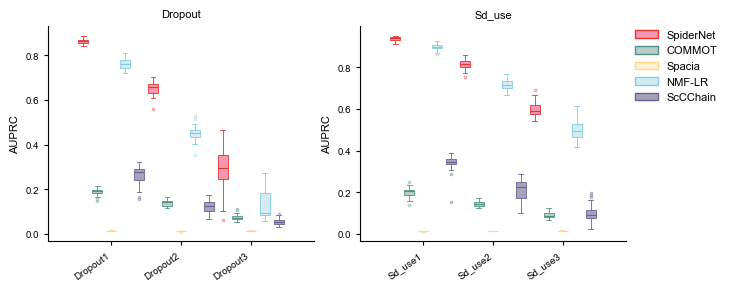

In [16]:
plot_df_auprc = load_metric_table(AUPRC_FILE, method_list=METHOD_LIST)
auprc_long_out, auprc_wide_out, auprc_found_summary = export_metric_tables(
    plot_df_auprc,
    value_col="values",
    stem="AUPRC_all",
)
auprc_summary = summarize_metric(plot_df_auprc, value_col="values", stem="AUPRC")

display(auprc_found_summary)
display(auprc_wide_out.head())
display(auprc_summary.head())

plot_metric_boxplot_faceted(
    df=plot_df_auprc,
    y_col="values",
    y_label="AUPRC",
    method_list=METHOD_LIST,
    edge_palette=EDGE_PALETTE,
    fill_palette=FILL_PALETTE,
    out_file=SUMMARY_OUT_DIR / "AUPRC_boxplot_by_setting_method.pdf",
)


## AUROC summary

,Setting,n_found_experiments
0,Dropout1,30
1,Dropout2,30
2,Dropout3,30
3,Sd_use1,30
4,Sd_use2,30
5,Sd_use3,30


Method,Setting,Experiment,SpiderNet,COMMOT,Spacia,NMF-LR,ScCChain
0,Dropout1,0,0.994166,0.447922,0.501084,0.979730,0.644565
1,Dropout1,1,0.995250,0.435978,0.489338,0.980113,0.754001
2,Dropout1,2,0.992357,0.423400,0.487834,0.980312,0.668098
3,Dropout1,3,0.993349,0.449805,0.497279,0.983109,0.681464
4,Dropout1,4,0.993529,0.448627,0.484566,0.972396,0.568211


,Setting,Method,mean_val,sd_val,n
0,Dropout1,SpiderNet,0.994030,0.001207,30
1,Dropout1,COMMOT,0.439638,0.017309,30
2,Dropout1,Spacia,0.486459,0.015457,30
3,Dropout1,NMF-LR,0.979790,0.003737,30
4,Dropout1,ScCChain,0.692965,0.048069,30


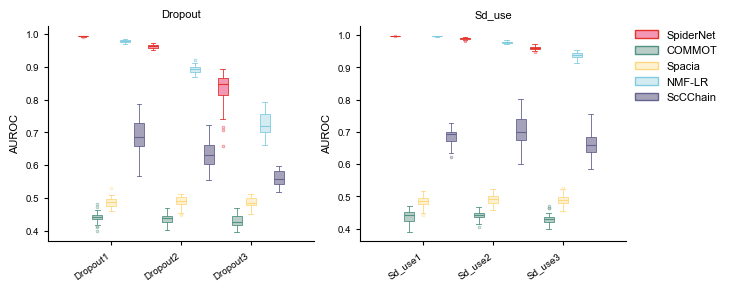

In [17]:
plot_df_auroc = load_metric_table(AUROC_FILE, method_list=METHOD_LIST)
auroc_long_out, auroc_wide_out, auroc_found_summary = export_metric_tables(
    plot_df_auroc,
    value_col="values",
    stem="AUROC_all",
)
auroc_summary = summarize_metric(plot_df_auroc, value_col="values", stem="AUROC")

display(auroc_found_summary)
display(auroc_wide_out.head())
display(auroc_summary.head())

plot_metric_boxplot_faceted(
    df=plot_df_auroc,
    y_col="values",
    y_label="AUROC",
    method_list=METHOD_LIST,
    edge_palette=EDGE_PALETTE,
    fill_palette=FILL_PALETTE,
    out_file=SUMMARY_OUT_DIR / "AUROC_boxplot_by_setting_method.pdf",
)


## SpiderNet loading block-mass ratio summary

Raw SpiderNet loading-table columns: ['Method', 'LR_loading_ratio', 'Sender_loading_ratio', 'Receiver_loading_ratio', 'MI1_component', 'MI2_component', 'Metric_definition', 'Normalization', 'Scoring', 'Setting', 'Experiment']


,Method,Setting,Experiment,Loading,LoadingRank_Ratio,setting_type
0,SpiderNet,Dropout1,0,LR Loading Rank Ratio,0.889035,Dropout
1,SpiderNet,Dropout1,1,LR Loading Rank Ratio,0.889365,Dropout
2,SpiderNet,Dropout1,2,LR Loading Rank Ratio,0.890801,Dropout
3,SpiderNet,Dropout1,3,LR Loading Rank Ratio,0.888422,Dropout
4,SpiderNet,Dropout1,4,LR Loading Rank Ratio,0.889854,Dropout


,Setting,Loading,mean_val,sd_val,n
0,Dropout1,LR Loading Rank Ratio,0.890538,0.006892,30
1,Dropout1,Sending Loading Rank Ratio,0.964531,0.020471,30
2,Dropout1,Receiving Loading Rank Ratio,0.954293,0.028693,30
3,Dropout2,LR Loading Rank Ratio,0.880618,0.040046,30
4,Dropout2,Sending Loading Rank Ratio,0.913638,0.043887,30


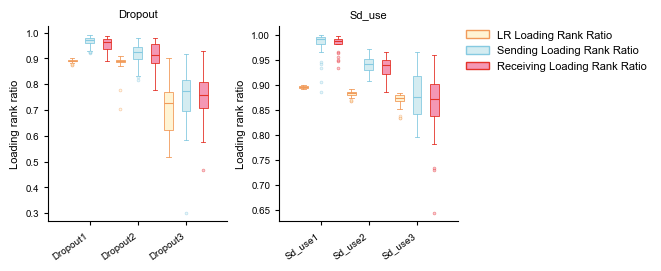

In [18]:
if not LOADING_FILE.is_file():
    raise FileNotFoundError(f"Cannot find SpiderNet loading summary file: {LOADING_FILE}")

raw_loading_df = pd.read_csv(LOADING_FILE)
print("Raw SpiderNet loading-table columns:", raw_loading_df.columns.tolist())

plot_df_loading = normalize_loading_table(raw_loading_df)

plot_df_loading.to_csv(SUMMARY_OUT_DIR / "LoadingRank_Ratio_long.csv", index=False)

loading_summary = (
    plot_df_loading.groupby(["Setting", "Loading"], observed=False)["LoadingRank_Ratio"]
    .agg(["mean", "std", "count"])
    .reset_index()
    .rename(columns={"mean": "mean_val", "std": "sd_val", "count": "n"})
)
loading_summary.to_csv(SUMMARY_OUT_DIR / "LoadingRank_Ratio_summary.csv", index=False)

display(plot_df_loading.head())
display(loading_summary.head())

plot_loading_boxplot_faceted(
    df=plot_df_loading,
    y_col="LoadingRank_Ratio",
    y_label="Loading rank ratio",
    loading_list=LOADING_ORDER,
    edge_palette=LOADING_EDGE_PALETTE,
    fill_palette=LOADING_FILL_PALETTE,
    out_file=SUMMARY_OUT_DIR / "LoadingRankRatio_boxplot_by_setting_loading.pdf",
)


## Statistical tests

In [10]:
loading_ttest = one_sample_ttests_vs_one(plot_df_loading)
loading_ttest.to_csv(SUMMARY_OUT_DIR / "LoadingRankRatio_ttest_pvalues.csv", index=False)

auprc_pairwise = pairwise_rank_tests_by_setting(plot_df_auprc, value_col="values")
auroc_pairwise = pairwise_rank_tests_by_setting(plot_df_auroc, value_col="values")

auprc_pairwise.to_csv(SUMMARY_OUT_DIR / "AUPRC_pairwise_rank_tests_by_setting.csv", index=False)
auroc_pairwise.to_csv(SUMMARY_OUT_DIR / "AUROC_pairwise_rank_tests_by_setting.csv", index=False)

display(loading_ttest.head())
display(auprc_pairwise.head())
display(auroc_pairwise.head())


,Setting,Loading,p_value,mean_val,n
0,Dropout1,LR Loading Rank Ratio,1.271904e-36,0.890538,30
1,Dropout1,Sending Loading Rank Ratio,2.134442e-10,0.964531,30
2,Dropout1,Receiving Loading Rank Ratio,1.323979e-09,0.954293,30
3,Dropout2,LR Loading Rank Ratio,3.692584e-16,0.880618,30
4,Dropout2,Sending Loading Rank Ratio,1.173109e-11,0.913638,30


,Setting,method_1,method_2,p_value,mean_1,mean_2,n_1,n_2
0,Dropout1,SpiderNet,COMMOT,3.019859e-11,0.864556,0.190393,30,30
1,Dropout1,SpiderNet,Spacia,3.019859e-11,0.864556,0.013985,30,30
2,Dropout1,SpiderNet,NMF-LR,3.019859e-11,0.864556,0.763451,30,30
3,Dropout1,SpiderNet,ScCChain,3.019859e-11,0.864556,0.265880,30,30
4,Dropout1,COMMOT,Spacia,3.019859e-11,0.190393,0.013985,30,30


,Setting,method_1,method_2,p_value,mean_1,mean_2,n_1,n_2
0,Dropout1,SpiderNet,COMMOT,3.019859e-11,0.994030,0.439638,30,30
1,Dropout1,SpiderNet,Spacia,3.019859e-11,0.994030,0.486459,30,30
2,Dropout1,SpiderNet,NMF-LR,3.019859e-11,0.994030,0.979790,30,30
3,Dropout1,SpiderNet,ScCChain,3.019859e-11,0.994030,0.692965,30,30
4,Dropout1,COMMOT,Spacia,1.956780e-10,0.439638,0.486459,30,30


## Final output check

In [11]:
final_outputs = sorted([p.name for p in SUMMARY_OUT_DIR.iterdir()])
pd.DataFrame({"Saved file": final_outputs})


,Saved file
0,AUPRC_all_found_summary.csv
1,AUPRC_all_long.csv
2,AUPRC_all_wide.csv
3,AUPRC_boxplot_by_setting_method.pdf
4,AUPRC_pairwise_rank_tests_by_setting.csv
5,AUPRC_summary_by_setting_method.csv
6,AUROC_all_found_summary.csv
7,AUROC_all_long.csv
8,AUROC_all_wide.csv
9,AUROC_boxplot_by_setting_method.pdf
